# Data Analyst Job Market Analysis using Python

## Objective
Analyze Data Analyst job postings to understand salary trends, in-demand skills, locations, companies, work arrangements, and job characteristics.

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df = pd.read_csv('C:/Users/sagar/Downloads/Data-Analyst-Job-Market-EDA/data/Data_Analyst_Jobs.csv')
df.head()

,title,company_name,location,via,description,extensions,job_id,thumbnail,posted_at,schedule_type,work_from_home,salary,search_term,date_time,search_location,commute_time,salary_pay,salary_rate,salary_avg,salary_min,salary_max,salary_hourly,salary_yearly,salary_standardized,description_tokens,salary_midpoint,skill_sql,skill_python,skill_excel,skill_tableau,skill_power_bi,skill_r,skill_aws,skill_spark,skill_hadoop
0,Data Analyst,Meta,Anywhere,via LinkedIn,In the intersection of compliance and analytic...,"['15 hours ago', '101K–143K a year', 'Work fro...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,NaN,Full-time,True,101K–143K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,101K–143K,a year,122000.0,101000.0,143000.0,NaN,122000.0,122000.0,"['tableau', 'r', 'python', 'sql']",122000.0,True,True,False,True,False,True,False,False,True
1,Data Analyst,ATC,United States,via LinkedIn,Job Title: Entry Level Business Analyst / Prod...,"['12 hours ago', 'Full-time', 'Health insurance']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QiLCJodGlkb2...,https://encrypted-tbn0.gstatic.com/images?q=tb...,NaN,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],NaN,False,False,False,False,False,False,False,False,False
2,Aeronautical Data Analyst,"Garmin International, Inc.","Olathe, KS",via Indeed,Overview:\n\nWe are seeking a full-time...\nAe...,"['18 hours ago', 'Full-time']",eyJqb2JfdGl0bGUiOiJBZXJvbmF1dGljYWwgRGF0YSBBbm...,NaN,NaN,Full-time,NaN,NaN,data analyst,2023-08-04 03:00:13.797776,United States,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['sql'],NaN,True,False,False,False,False,False,False,False,False
3,Data Analyst - Consumer Goods - Contract to Hire,Upwork,Anywhere,via Upwork,Enthusiastic Data Analyst for processing sales...,"['12 hours ago', '15–25 an hour', 'Work from h...",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgLSBDb25zdW...,NaN,NaN,Contractor,True,15–25 an hour,data analyst,2023-08-04 03:00:13.797776,United States,NaN,15–25,an hour,20.0,15.0,25.0,20.0,NaN,41600.0,"['powerpoint', 'excel', 'power_bi']",20.0,False,False,True,False,True,False,False,False,False
4,Data Analyst | Workforce Management,Krispy Kreme,United States,via LinkedIn,Overview of Position\n\nThis position will be ...,"['7 hours ago', '90K–110K a year', 'Contractor']",eyJqb2JfdGl0bGUiOiJEYXRhIEFuYWx5c3QgfCBXb3JrZm...,https://encrypted-tbn0.gstatic.com/images?q=tb...,NaN,Contractor,NaN,90K–110K a year,data analyst,2023-08-04 03:00:13.797776,United States,NaN,90K–110K,a year,100000.0,90000.0,110000.0,NaN,100000.0,100000.0,"['powerpoint', 'excel', 'outlook', 'word']",100000.0,False,False,True,False,False,False,False,False,False


## 1. Data Understanding

In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 61953
Columns: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61953 entries, 0 to 61952
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                61953 non-null  object 
 1   company_name         61953 non-null  object 
 2   location             61916 non-null  object 
 3   via                  61944 non-null  object 
 4   description          61953 non-null  object 
 5   extensions           61953 non-null  object 
 6   job_id               61953 non-null  object 
 7   thumbnail            38194 non-null  object 
 8   posted_at            0 non-null      float64
 9   schedule_type        61707 non-null  object 
 10  work_from_home       27980 non-null  object 
 11  salary               10088 non-null  object 
 12  search_term          61953 non-null  object 
 13  date_time            61953 non-null  object 
 14  search_location      61953 non-null  object 
 15  commute_time

In [7]:
# Missing values
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
}).sort_values('missing_count', ascending=False)

missing.head(15)

,missing_count,missing_percent
posted_at,61953,100.00
commute_time,61953,100.00
salary_yearly,57884,93.43
salary_hourly,56053,90.48
salary_min,52441,84.65
salary_max,52441,84.65
salary_midpoint,52441,84.65
salary,51865,83.72
salary_rate,51865,83.72
salary_avg,51865,83.72


**Insight:** Only ~16% of postings (10,088 of 61,953) have a usable standardized salary — most fields tied to salary (hourly/yearly/min/max) are 80–93% missing. `posted_at` and `commute_time` are 100% empty and effectively unusable. Any salary conclusion below should be read as *indicative of postings that disclosed pay*, not the full market.

In [8]:
# Duplicate check
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


**Insight:** Zero duplicate rows — the dataset is already de-duplicated, so no cleanup is needed before analysis.

## 2. Salary Analysis

In [9]:
salary = df['salary_standardized'].dropna()
salary.describe()

count     10088.000000
mean      92289.425683
std       43277.933820
min       15080.000000
25%       62400.000000
50%       88400.000000
75%      117500.000000
max      624000.000000
Name: salary_standardized, dtype: float64

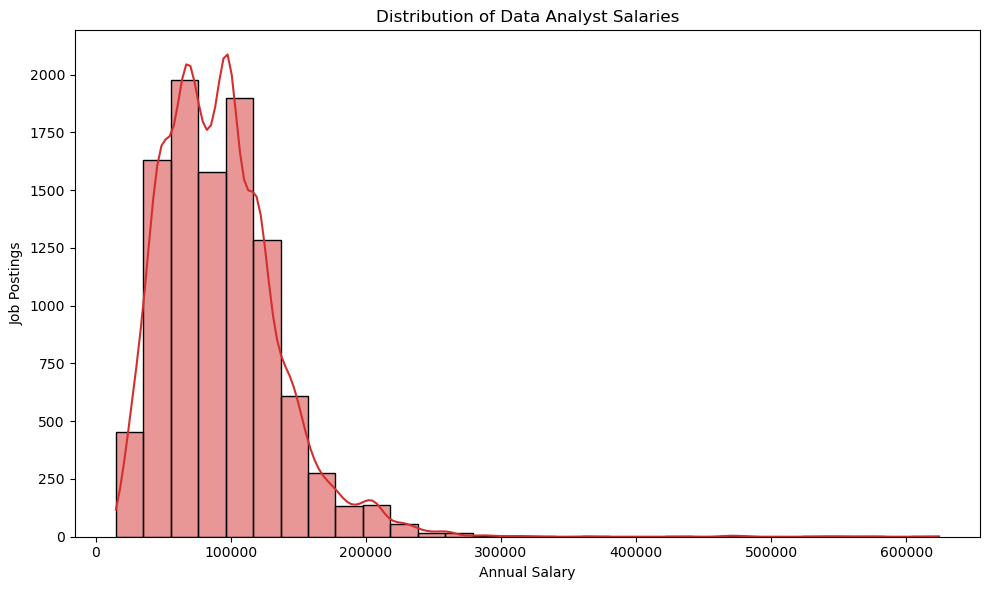

In [26]:
plt.figure(figsize=(10,6))
sns.histplot(salary, bins=30, kde=True,color="#D32F2F")
plt.title('Distribution of Data Analyst Salaries')
plt.xlabel('Annual Salary')
plt.ylabel('Job Postings')
plt.tight_layout()
plt.show()

**Insight:** The median advertised salary is **$88,400** (mean **$92,289**), with the middle 50% of postings falling between **$62,400 and $117,500**. The distribution is right-skewed with a long tail up to $624,000, so the median is a more reliable 'typical salary' figure than the mean.

## 3. Top Job Titles

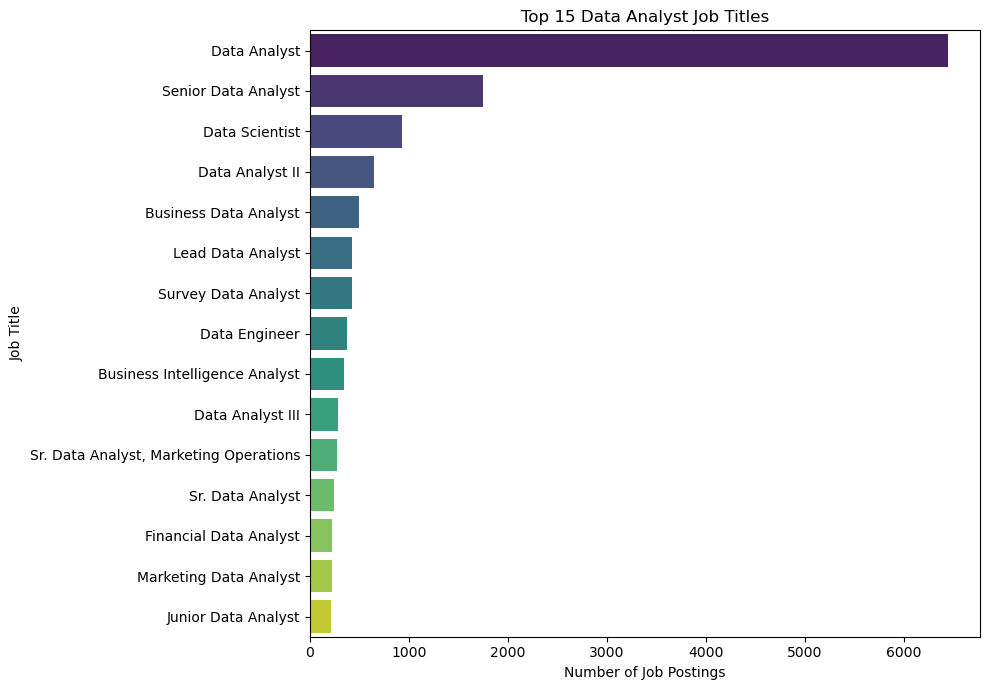

In [28]:
top_titles = df['title'].value_counts().head(15)
plt.figure(figsize=(10,7))
sns.barplot(
    x=top_titles.values,
    y=top_titles.index,
    hue=top_titles.index,
    palette="viridis",
    legend=False
)
plt.title('Top 15 Data Analyst Job Titles')
plt.xlabel('Number of Job Postings')
plt.ylabel('Job Title')
plt.tight_layout()
plt.show()

**Insight:** "Data Analyst" is the single largest title (6,444 postings, ~10% of all listings), but the results are noisy — related-but-distinct roles like *Data Scientist* (931), *Data Engineer* (375), and *Business Intelligence Analyst* (343) also surface, alongside seniority variants (*Senior*, *Lead*, *II/III*). This suggests the underlying job search query pulled in adjacent data roles, not just pure "Data Analyst" listings.

## 4. Top Hiring Companies

In [29]:
top_companies = df['company_name'].value_counts().head(15)
plt.figure(figsize=(10,7))
sns.barplot(
    x=top_companies.values,
    y=top_companies.index,
    hue=top_companies.index,
    palette="Blues",
    legend=False
)plt.title('Top 15 Hiring Companies')
plt.xlabel('Number of Job Postings')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3701477478.py, line 9)

**Insight:** The top "hiring companies" are dominated by staffing/freelance marketplaces (**Upwork**: 7,533, **Talentify.io**: 2,118, **Dice**: 862) rather than direct employers, which inflates their apparent hiring volume. **Walmart** (1,829) is the largest genuine direct employer in the top 10 — worth separating platforms from actual companies before drawing hiring-demand conclusions.

## 5. Location Analysis

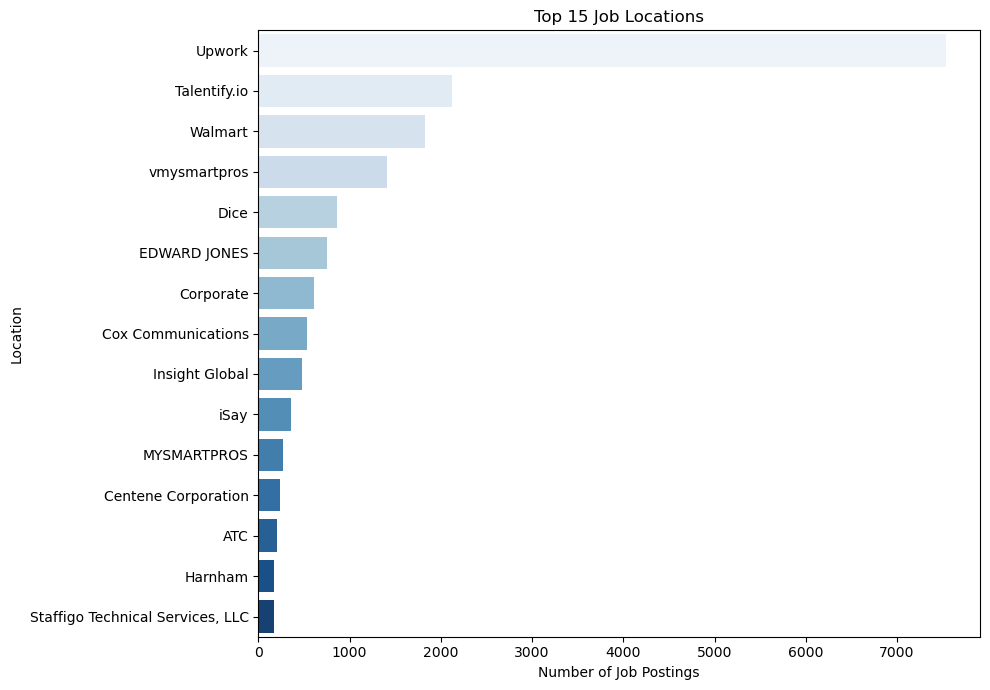

In [32]:
top_locations = df['location'].value_counts().head(15)
plt.figure(figsize=(10,7))
sns.barplot(
    x=top_companies.values,
    y=top_companies.index,
    hue=top_companies.index,
    palette="Blues",
    legend=False
)
plt.title('Top 15 Job Locations')
plt.xlabel('Number of Job Postings')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

**Insight:** ~72% of postings have no specific city — they're labeled **"Anywhere"** (27,982) or just **"United States"** (15,558), reflecting how common remote/national postings are for this role. Among postings with a real city, the Midwest and Plains states lead: **Oklahoma City, OK** (1,437), **Kansas City, MO** (1,413), and **Denver, CO** (1,062).

## 6. Work From Home Analysis

work_from_home
NaN     33973
True    27980
Name: count, dtype: int64


C:\Users\sagar\AppData\Local\Temp\ipykernel_1512\3176200975.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='work_from_home',palette='Set2',


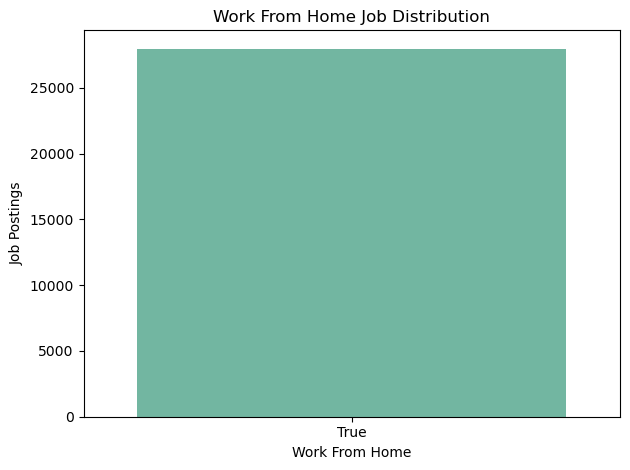

In [34]:
if 'work_from_home' in df.columns:
    print(df['work_from_home'].value_counts(dropna=False))
    sns.countplot(data=df, x='work_from_home',palette='Set2',
    legend=False)
    plt.title('Work From Home Job Distribution')
    plt.xlabel('Work From Home')
    plt.ylabel('Job Postings')
    plt.tight_layout()
    plt.show()

**Insight:** The `work_from_home` field is a one-sided flag (only `True` or missing — there's no explicit `False`). Of all postings, **45%** (27,980 / 61,953) are explicitly flagged remote-eligible; the rest simply don't state it, so this likely *undercounts* true remote availability rather than confirming onsite-only roles.

## 7. In-Demand Skills

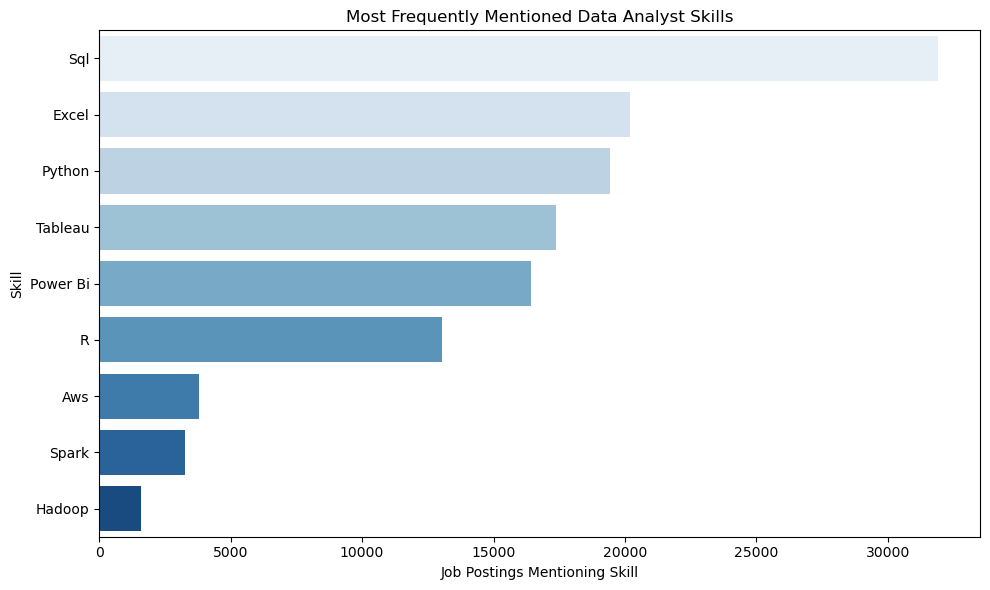

In [35]:
skill_cols = [c for c in df.columns if c.startswith('skill_')]
skill_counts = df[skill_cols].sum().sort_values(ascending=False)

skill_counts.index = [
    x.replace('skill_', '').replace('_', ' ').title()
    for x in skill_counts.index
]

plt.figure(figsize=(10,6))
sns.barplot(
    x=skill_counts.values,
    y=skill_counts.index,
    hue=skill_counts.index,
    palette='Blues',
    legend=False
)
plt.title('Most Frequently Mentioned Data Analyst Skills')
plt.xlabel('Job Postings Mentioning Skill')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

**Insight:** **SQL** is the clear baseline skill, appearing in **51.5%** of postings — more than any other. **Excel** (32.6%), **Python** (31.4%), **Tableau** (28.0%), and **Power BI** (26.5%) form a second tier of widely expected tools. Big-data/cloud skills — **AWS** (6.1%), **Spark** (5.3%), **Hadoop** (2.6%) — are rare, appearing in fewer than 1 in 10 postings.

## 8. Skill vs Salary

In [16]:
skill_salary = []

for col in [c for c in df.columns if c.startswith('skill_')]:
    avg_salary = df.loc[df[col] == True, 'salary_standardized'].mean()
    skill_salary.append([col.replace('skill_', '').replace('_', ' ').title(), avg_salary])

skill_salary = pd.DataFrame(skill_salary, columns=['Skill', 'Average Salary'])
skill_salary.sort_values('Average Salary', ascending=False)

,Skill,Average Salary
7,Spark,122493.344582
8,Hadoop,118985.282861
6,Aws,114829.820629
1,Python,104779.224716
5,R,99324.107417
0,Sql,97897.469773
3,Tableau,96491.216555
4,Power Bi,91994.109768
2,Excel,83695.495098


**Insight:** The skills with the *highest* average salary are the *least* common ones: **Spark** ($122,493), **Hadoop** ($118,985), and **AWS** ($114,830) all pay well above the overall median despite appearing in under 7% of postings. Core, high-demand skills pay less on average — **Excel** ($83,695) and **Power BI** ($91,994) sit at the bottom of the salary ranking — suggesting they're table-stakes rather than differentiators.

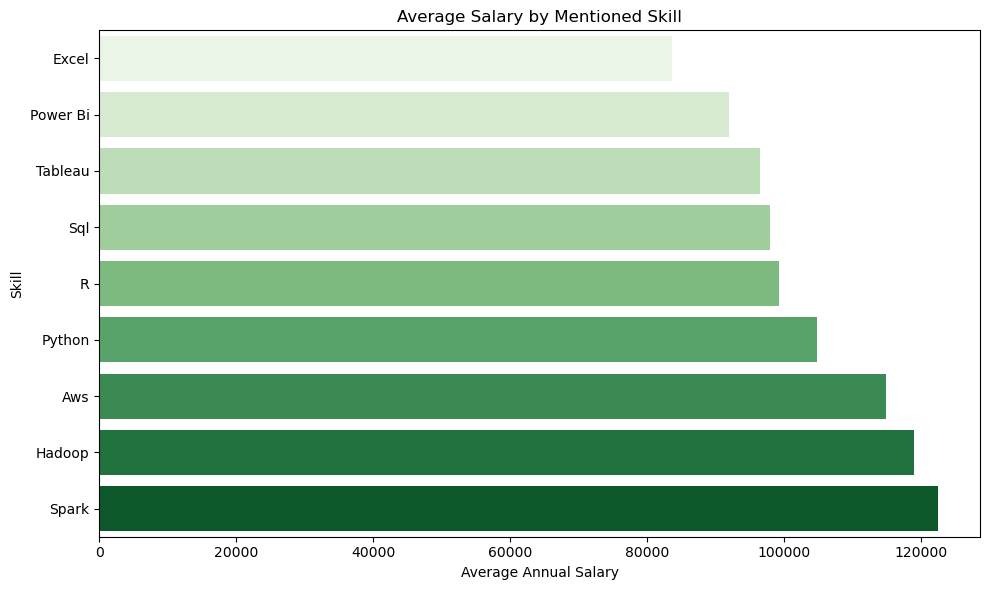

In [37]:
plt.figure(figsize=(10,6))
plot_df = skill_salary.dropna().sort_values('Average Salary')
sns.barplot(
    data=plot_df,
    x='Average Salary',
    y='Skill',
    hue='Skill',
    palette='Greens',
    legend=False
)
plt.title('Average Salary by Mentioned Skill')
plt.xlabel('Average Annual Salary')
plt.ylabel('Skill')
plt.tight_layout()
plt.show()

**Insight:** There's a clear inverse pattern between skill *prevalence* and skill *pay premium* — the chart shows niche big-data/cloud skills (Spark, Hadoop, AWS, Python) clustered at the top of the salary scale, while the most commonly-required tools (Excel, Power BI, Tableau) sit at the bottom. This implies the fastest way to raise expected pay is layering a scarce technical skill (e.g., Spark or AWS) on top of the SQL/Excel baseline, not just knowing SQL/Excel alone.

## 9. Salary by Work Arrangement

In [38]:
if 'work_from_home' in df.columns:
    salary_wfh = df.groupby('work_from_home')['salary_standardized'].agg(['count','mean','median']).round(2)
    salary_wfh

**Insight:** Mean salary is nearly identical for remote vs. non-remote-flagged postings (~$92,000 either way), but the **median is lower for remote roles** ($85,000 vs. $91,930) — remote postings likely include a wider spread of seniority/pay levels, pulling the median down even though the average holds steady due to some high-paying outliers.

## 10. Correlation Analysis

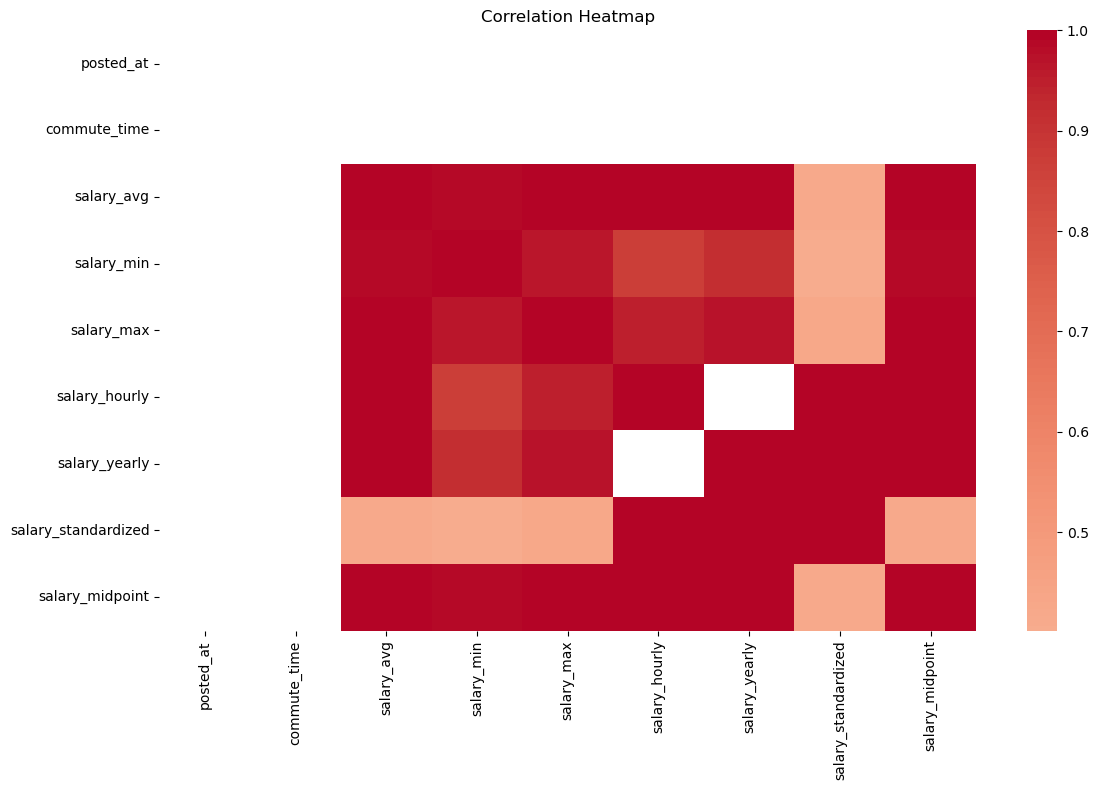

In [19]:
num_cols = df.select_dtypes(include=np.number).columns
corr = df[num_cols].corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Insight:** `salary_standardized` correlates only moderately (r ≈ 0.40–0.42) with the raw `salary_min`, `salary_max`, `salary_avg`, and `salary_midpoint` fields — it isn't a simple copy of them, it's a genuinely derived/normalized figure (likely reconciling hourly vs. yearly pay onto one scale). `posted_at` and `commute_time` show no correlation because they're 100% missing.

## 12. Employment Type & Job Source Platforms

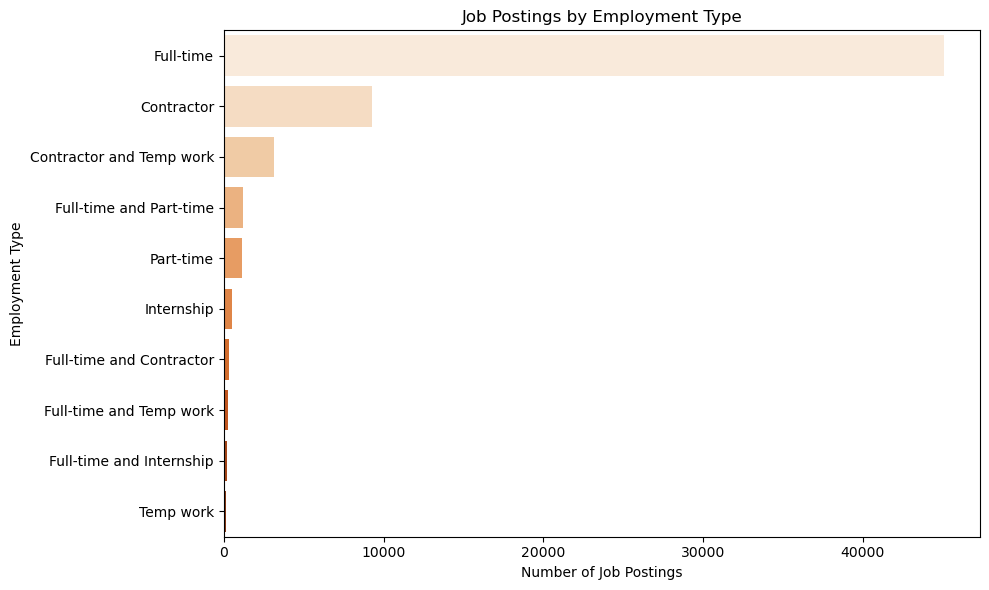

In [39]:
schedule_counts = df['schedule_type'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=schedule_counts.values,
    y=schedule_counts.index,
    hue=schedule_counts.index,
    palette="Oranges",
    legend=False
)
plt.title('Job Postings by Employment Type')
plt.xlabel('Number of Job Postings')
plt.ylabel('Employment Type')
plt.tight_layout()
plt.show()

**Insight:** **Full-time** roles dominate at 45,082 postings (~73%), but a meaningful share is non-permanent: **Contractor** (9,284) plus **Contractor and Temp work** (3,130) together make up over **20%** of listings — data analyst hiring leans heavily full-time, but contract work is a substantial secondary path into the field.

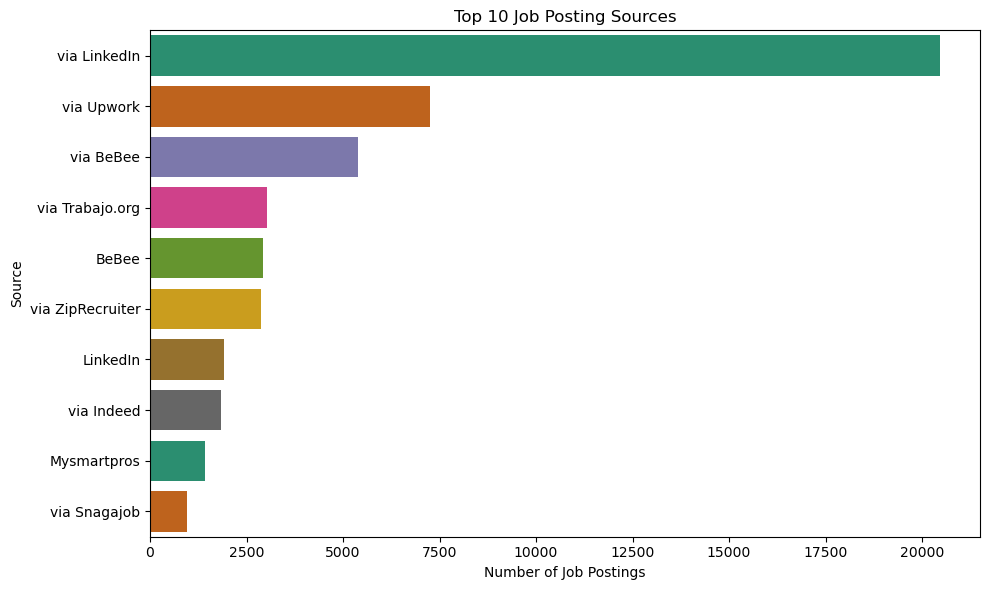

In [40]:
top_via = df['via'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_via.values,
    y=top_via.index,
    hue=top_via.index,
    palette="Dark2",
    legend=False
)
plt.title('Top 10 Job Posting Sources')
plt.xlabel('Number of Job Postings')
plt.ylabel('Source')
plt.tight_layout()
plt.show()

**Insight:** **LinkedIn** is the dominant aggregation source (20,475 postings, ~33%), far ahead of freelance marketplaces like **Upwork** (7,261) and regional boards like **BeBee** (5,378 + 2,937 unlabeled). The heavy presence of gig platforms (Upwork, Trabajo.org) alongside mainstream job boards confirms this dataset blends traditional employment with freelance/contract gig postings — reinforcing the employment-type finding above.

## 11. Key Business Questions

Use the outputs above to answer:

1. What are the most common Data Analyst job titles?
2. Which companies post the most jobs?
3. Which locations have the most opportunities?
4. What is the typical advertised salary?
5. Which skills are most demanded?
6. Which skills are associated with higher advertised salaries?
7. How common are remote opportunities?
8. Which work arrangement has the higher median salary?
9. What relationships exist among salary and other numerical variables?
10. What skills should an aspiring Data Analyst prioritize?

## Final Recommendations

- Prioritize the skills with the highest demand in the dataset.
- Compare salary-related findings with skill demand rather than relying on salary alone.
- Target locations and companies with strong job volume.
- Treat salary comparisons carefully because advertised salary coverage may vary by posting.
- Use the findings as market evidence, not as a guarantee of individual salary outcomes.

## Summary of Key Insights

1. Only ~16% of postings disclose a standardized salary — treat pay findings as directional, not exhaustive.
2. Median salary is **$88,400**; the distribution is right-skewed with outliers up to $624,000.
3. "Data Analyst" is the top title (~10%), but the dataset also captures adjacent roles (Data Scientist, Data Engineer, BI Analyst).
4. Reported top "employers" are mostly staffing/freelance platforms (Upwork, Talentify, Dice) — Walmart is the top genuine direct employer.
5. 72% of postings have no specific city ("Anywhere"/"United States"); among city-specific roles, the Midwest leads (Oklahoma City, Kansas City, Denver).
6. At least 45% of postings are explicitly remote-eligible, likely an undercount since the flag has no explicit "False" value.
7. **SQL** (51.5%) is the single most in-demand skill, followed by Excel, Python, Tableau, and Power BI.
8. Niche technical skills — **Spark, Hadoop, AWS** — pay the highest average salaries despite appearing in under 7% of postings.
9. The most commonly required skills (Excel, Power BI) are associated with the *lowest* average salaries — they're baseline expectations, not differentiators.
10. Remote and onsite postings have similar mean pay (~$92K), but remote postings have a lower median (~$85K vs ~$92K), suggesting wider pay variance in remote listings.
11. Full-time roles are ~73% of postings; contract/temp work makes up a notable ~20%+, showing gig-style hiring is common in this field.
12. LinkedIn is the dominant source platform (~33%), followed by gig/freelance marketplaces like Upwork.
13. Standardized salary correlates only moderately (r≈0.40) with raw min/max/avg salary fields, confirming it's a genuinely normalized (not duplicated) metric.

